# [LAB-07] 8-1. 이원분산분석 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import melt

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## 📚 신입교사의 교육방법 채택 고민

### 당신은 한울고등학교의 연구교사로 부임했습니다.

지난 학기 학생 22명을 11명씩 나눠 두 가지 교육방법으로 가르친 뒤 국어·영어 시험을 치렀고 그 결과를 edu 데이터 셋으로 저장해 두었습니다.

이 데이터를 근거로 2번 교육 방법으로 바꾸려고 하는데, 어떤 선생님은 영어에서만 통한다고 합니다.

교육 방법과 과목, 두 요인이 각각 그리고 맞물려서 점수에 영향을 주는지 확인하세요.


### 💻 코드 작성

#### 데이터 가져오기

In [2]:
df1 = load_data('edu')
df1.head()

📚 두 가지 교육방법을 비교하기 위하여 능력이 비슷한 고등학교 학생 22명을 추출하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 교육방법으로 교육시킨 후 치른 학기말 시험 성적을 조사한 자료 (출처: 방송통신대학교 통계학 개론)


,교육방법,국어,영어
0,1,65,82
1,1,87,79
2,1,73,85
3,1,79,60
4,1,81,65


#### 데이터 재배치

In [3]:
df1_long = melt(df1, id_vars='교육방법',
                value_vars=['국어', '영어'],
                var_name='과목', value_name='점수')

print(f"관측치 개수: {len(df1_long)}")

df1_long.head()

관측치 개수: 44


,교육방법,과목,점수
0,1,국어,65
1,1,국어,87
2,1,국어,73
3,1,국어,79
4,1,국어,81


#### 이원 분산 분석

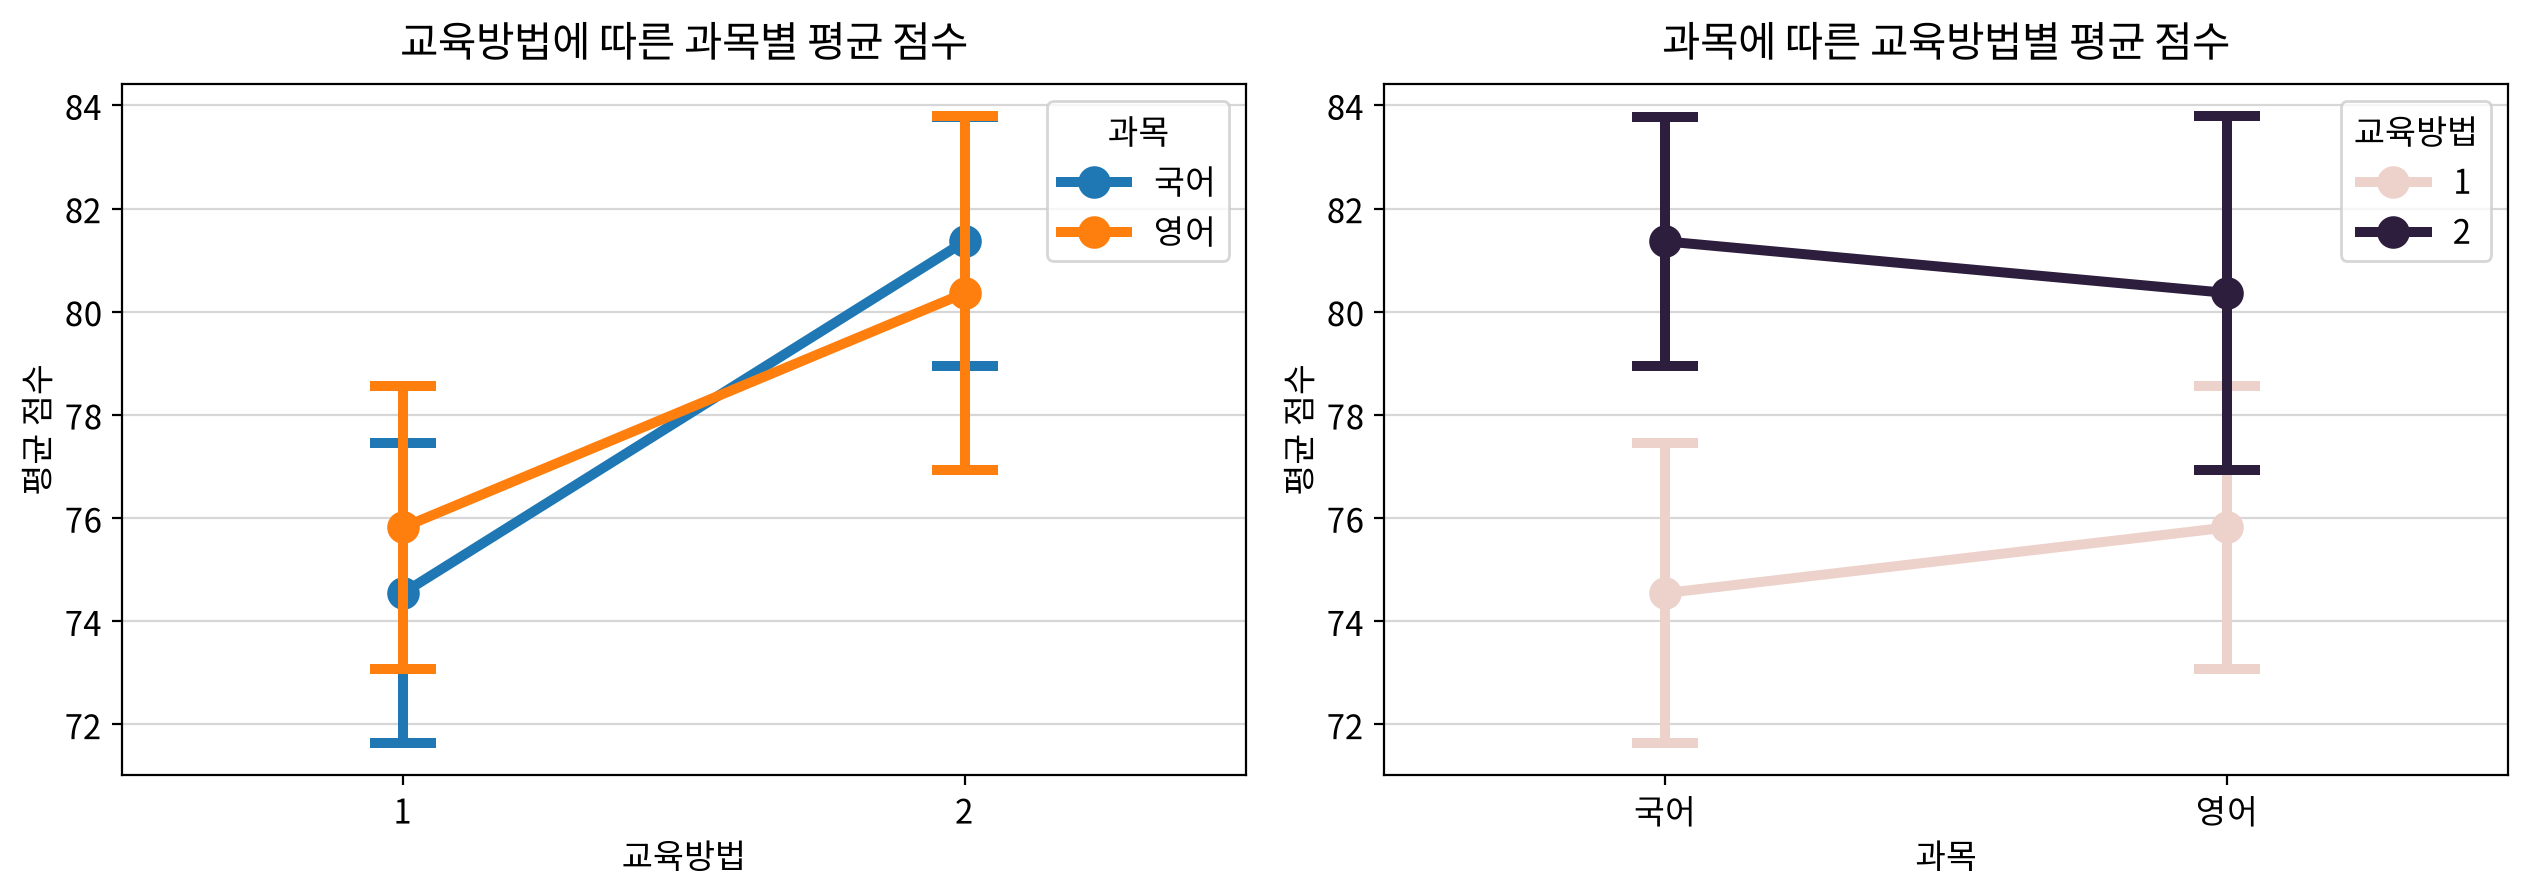

,test,Source,SS,DF,MS,F,p_unc,np2,significant,effect_size
0,two-way ANOVA,교육방법,355.114,1,355.114,3.846,0.057,0.088,False,Medium
1,two-way ANOVA,과목,0.205,1,0.205,0.002,0.963,0.000,False,Negligible
2,two-way ANOVA,교육방법 * 과목,14.205,1,14.205,0.154,0.697,0.004,False,Negligible
3,two-way ANOVA,Residual,3693.455,40,92.336,NaN,NaN,NaN,False,-


In [4]:
my_stats.anova_twoway(df1_long, y='점수', between=['교육방법', '과목'])

### 문제 풀이

#### 1. '과목'을 하나의 요인으로 다루려면 점수를 한 열에 모은 형태로 데이터를 재배치해야 합니다. 재배치된 데이터의 관측치(행) 개수는 몇 개 인가요?

- **정답**: `44`
- **복습 개념**: wide → long 데이터 재배치(melt)입니다. 이원분산분석은 "요인 = 열"이 아니라 "요인 = 값(범주)"인 long 형태를 요구합니다.
- **풀이 접근**: 원본은 22행 × (교육방법, 국어, 영어)입니다. '국어'·'영어'라는 **열 이름**을 '과목'이라는 요인의 **값**으로 내리고, 두 열에 흩어져 있던 점수를 '점수' 한 열로 합칩니다. 학생 한 명이 국어·영어 두 개의 관측치를 갖게 되므로 행 수는 2배가 됩니다.
- **근거(계산 결과)**: 22 × 2 = **44행**, 열은 (교육방법, 과목, 점수) 3개입니다. 위 코드의 출력에서 `관측치 개수: 44` 로 확인됩니다.
- **자주 하는 실수**: 원본 행 수 그대로 22라고 답하기 쉽습니다. 재배치 전 데이터는 한 행에 점수가 두 개 들어 있어 '과목'을 요인으로 쓸 수 없다는 점을 기억하세요. 이 44는 뒤에 나오는 잔차 자유도 40(= 44 − 4개 셀)과도 연결됩니다.

#### 2. 두 요인과 그 맞물림까지 한 번에 검정한 결과표의 세 효과 중,  검정통계량 값이 가장 큰 효과는 무엇인가요?

- **정답**: `교육방법`
- **복습 개념**: 이원분산분석 결과표 읽기입니다. 주효과 2개(교육방법, 과목)와 상호작용 효과 1개, 총 세 줄의 F 통계량을 비교합니다.
- **풀이 접근**: 재배치한 데이터에 두 요인(교육방법, 과목)을 넣어 이원분산분석을 수행한 뒤, 결과표의 F 열에서 Residual(잔차)을 뺀 세 행을 비교합니다.
- **근거(계산 결과)**: F(교육방법)=**3.846**, F(과목)=0.002, F(교육방법*과목)=0.154 입니다. 실제로 교육방법별 평균은 1번 75.182점, 2번 80.864점으로 5.7점가량 벌어지지만, 과목별 평균(국어 77.95 / 영어 78.09)은 사실상 같습니다. 점수 차이를 만드는 것은 과목이 아니라 교육방법입니다. ('교육방법 주효과'라고 답해도 같은 뜻입니다.)

#### 3. "2번 방법이 영어에서만 통한다"가 사실이라면 두 요인의 맞물림 효과가 드러나야 합니다. 이 효과의 유의확률(p-value) 은 얼마인가요? (소수 셋째 자리)

- **정답**: `0.697`
- **복습 개념**: 상호작용 효과(interaction effect)의 유의성 판정입니다. "한 요인의 효과가 다른 요인의 수준에 따라 달라지는가"를 검정하는 항입니다.
- **풀이 접근**: 결과표에서 `교육방법 * 과목` 행의 유의확률을 읽습니다. 상호작용 그래프에서 두 선이 평행한지 교차하는지를 보는 것과 같은 이야기입니다.
- **근거(계산 결과)**: p = **0.697** 로 0.05보다 훨씬 큽니다 → 상호작용은 없습니다. 조합별 평균을 보면 교육방법 2의 이득이 국어에서 +6.8점, 영어에서 +4.5점으로 방향이 같아 선이 교차하지 않습니다. 즉 "2번 방법이 영어에서만 통한다"는 주장은 데이터로 지지되지 않습니다.

#### 4. 유의수준 **5%** 기준으로, 세 효과 중 유의하다고 판정되는 효과의 개수는 몇 개 인가요?

- **정답**: `0`
- **복습 개념**: 유의수준 α=0.05 기준의 귀무가설 기각 판정입니다. 세 효과 모두 기각에 실패했습니다.
- **풀이 접근**: 결과표의 p값 세 개(0.057, 0.963, 0.697)를 0.05와 비교해 작은 것의 개수를 셉니다.
- **근거(계산 결과)**: 0.057 > 0.05, 0.963 > 0.05, 0.697 > 0.05 → 유의한 효과는 **0개**입니다. 결과표의 `significant` 열도 세 줄 모두 False입니다.
- **함께 생각해 볼 점**: 교육방법의 p=0.057은 0.05를 간발의 차로 넘긴 값입니다. 유의수준을 0.10으로 잡았다면 유의했을 것이고, 표본이 22명(집단당 11명)으로 매우 작아 검정력이 낮다는 점도 함께 생각해 보세요. "유의하지 않다"가 "효과가 없다"를 증명해 주지는 않습니다.

#### 5. 당신이 교육 방법의 변경을 주장하려면 2번 교육방법의 효과를 입증해야 합니다. 2번 교육 효과의 효과크기는 결과표에서 어떤 등급으로 판정되었나요?

- **정답**: `Medium`
- **복습 개념**: 부분 에타제곱(partial η², np2)에 의한 효과크기 판정입니다. p값은 '효과가 있느냐', 효과크기는 '얼마나 크냐'라는 서로 다른 질문에 답합니다.
- **풀이 접근**: 결과표의 `np2` 열과 `effect_size` 열을 확인합니다. 통상 기준은 0.01(Small) / 0.06(Medium) / 0.14(Large)입니다.
- **근거(계산 결과)**: np2(교육방법) = **0.088** 로 0.06 이상 0.14 미만이므로 `Medium` 입니다. 반면 과목(0.000)과 상호작용(0.004)은 `Negligible` 입니다. (한글로 '중간'이라고 답해도 같은 뜻입니다.)
- **결론**: 유의하지는 않았지만 교육방법의 효과크기는 Medium이고 p도 0.057로 경계선에 걸려 있습니다. 그러니 "전면 교체하자"고 단정할 근거도, "효과가 없다"고 접을 근거도 아직 없습니다. 당신이 내려야 하는 답은 **표본을 늘려 다시 검정해 보자**입니다.

## 📚 응급의료센터의 표준 해독제 선정

### 당신은 독성학연구소의 신입 연구원입니다.

연구소는 세 가지 독극물(P1·P2·P3)에 중독된 개체에 네 가지 해독제(T1~T4)를 투여하고 생존시간을 측정하는 실험을 마쳤고, 그 결과를 poisons 데이터 셋으로 저장해 두었습니다.

응급의료센터는 "현장에서는 어떤 독극물에 중독됐는지 확인할 시간이 없으니 해독제 하나를 표준 프로토콜로 채택하고 싶다"고 요청해 왔습니다.

독극물 종류와 해독제, 두 요인이 각각 그리고 맞물려서 생존시간에 영향을 주는지 확인하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [5]:
df2 = load_data('poisons')
df2.head()

📚 독극물 종류별로 동물의 생존시간을 기록한 실험 데이터 (출처: 방송통신대학교 통계학 개론)


,time,poison,treat
0,3.800,P1,T1
1,2.700,P1,T1
2,1.700,P1,T1
3,2.200,P1,T1
4,0.700,P1,T1


#### 실험 설계 확인

In [6]:
print(f"독극물 종류: {sorted(df2['poison'].unique())}")
print(f"해독제 종류: {sorted(df2['treat'].unique())}")
print(f"처리 조합(셀) 수: {df2.groupby(['poison', 'treat']).ngroups}")
print(f"조합당 개체 수: {df2.groupby(['poison', 'treat']).size().unique()}")

독극물 종류: ['P1', 'P2', 'P3']
해독제 종류: ['T1', 'T2', 'T3', 'T4']
처리 조합(셀) 수: 12
조합당 개체 수: [30]


#### 이원 분산 분석

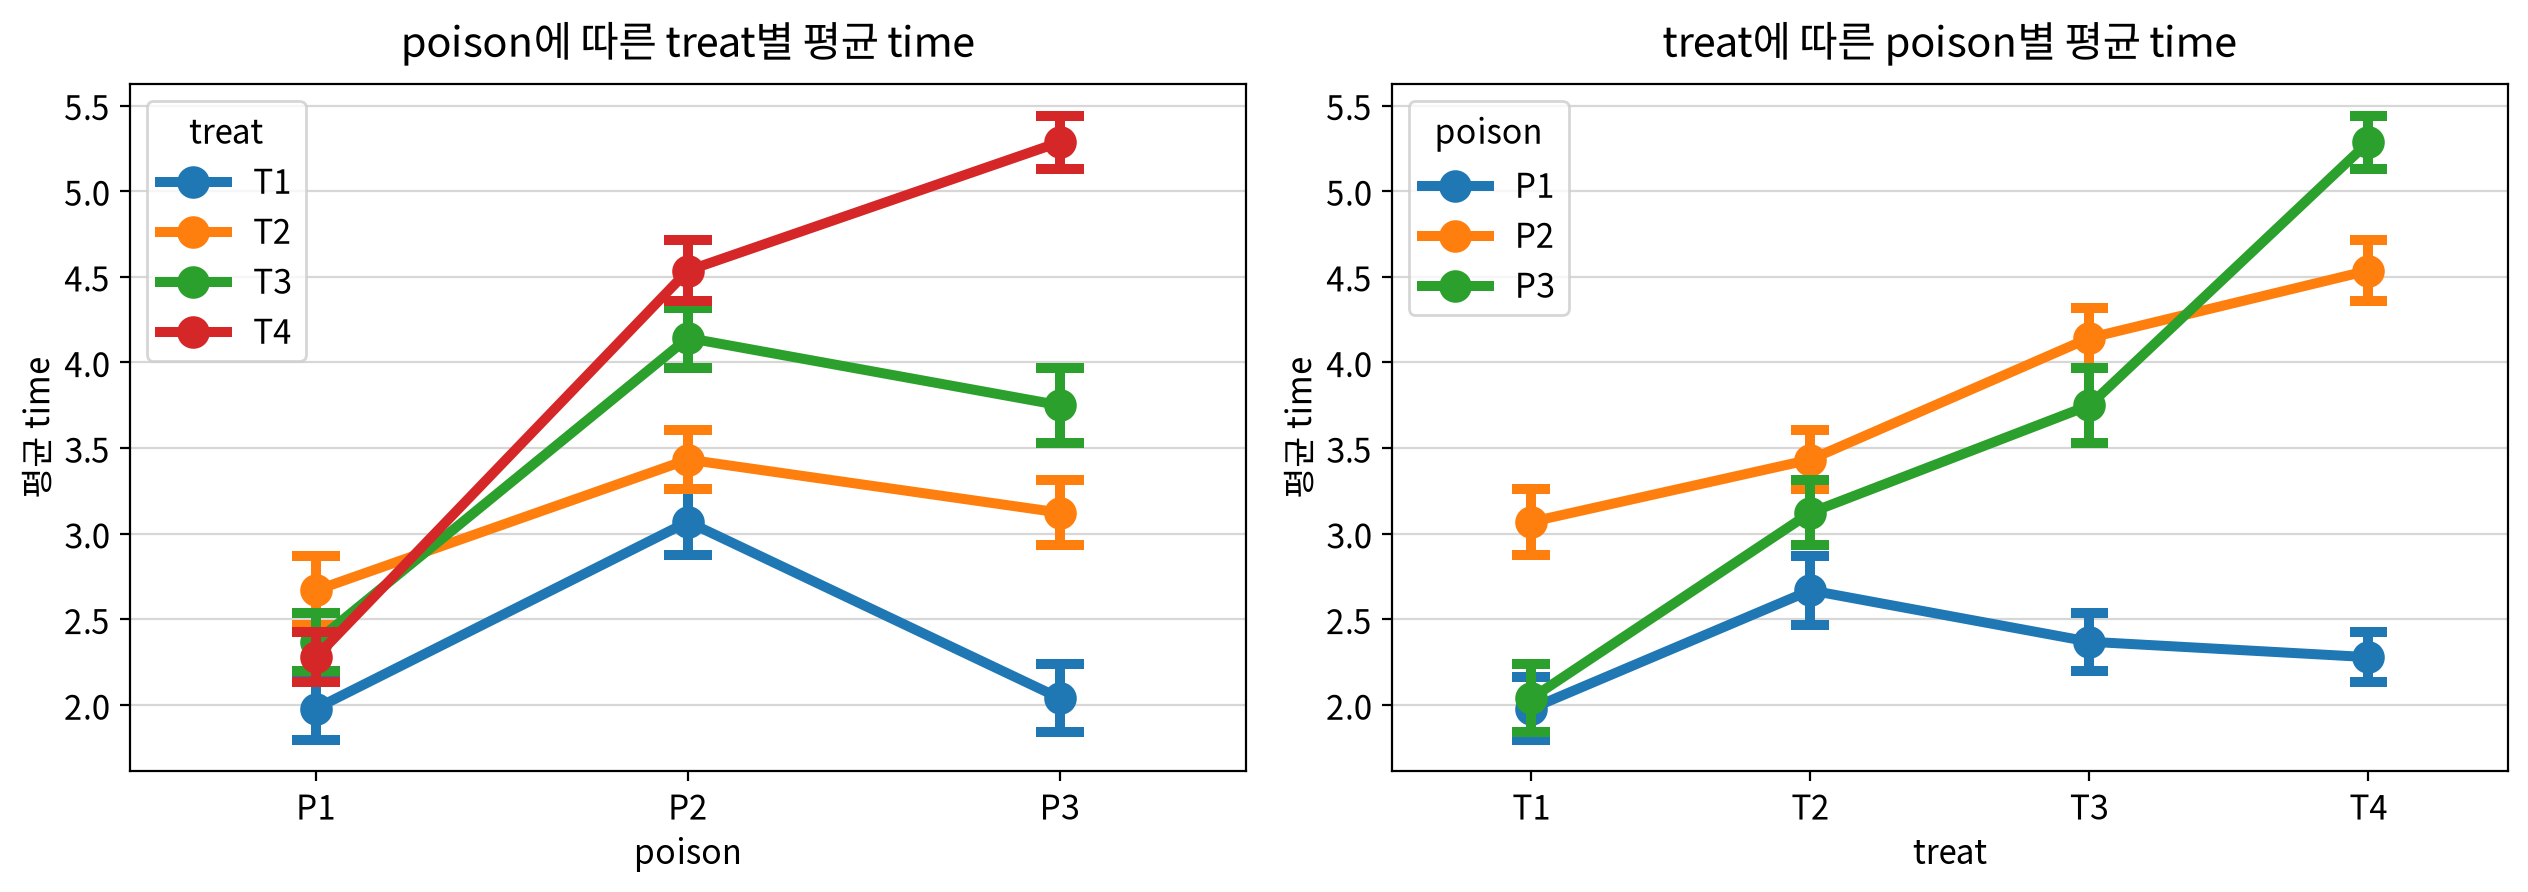

,test,Source,SS,DF,MS,F,p_unc,np2,significant,effect_size
0,two-way ANOVA,poison,148.976,2,74.488,74.722,0.000,0.300,True,Large
1,two-way ANOVA,treat,131.261,3,43.754,43.891,0.000,0.275,True,Large
2,two-way ANOVA,poison * treat,81.382,6,13.564,13.606,0.000,0.190,True,Large
3,two-way ANOVA,Residual,346.910,348,0.997,NaN,NaN,NaN,False,-


In [7]:
my_stats.anova_twoway(df2, y='time', between=['poison', 'treat'])

#### 조합별 평균 생존시간 (상호작용 해석)

In [8]:
df2.pivot_table(index='poison', columns='treat', values='time', aggfunc='mean').round(3)

treat,T1,T2,T3,T4
poison,,,,
P1,1.980,2.670,2.370,2.280
P2,3.070,3.433,4.143,4.537
P3,2.040,3.123,3.750,5.287


### 문제 풀이

#### 1. 분석에 앞서 실험이 어떻게 짜여 있는지부터 확인해야 합니다. 두 요인의 수준을 모두 맞물린 처리 조합(셀)은 몇 개 인가요?

- **정답**: `12`
- **복습 개념**: 이원분산분석이 전제하는 요인설계(factorial design)입니다. 두 요인의 수준을 모두 조합한 만큼 셀이 만들어지고, 각 셀의 평균이 분석의 기본 단위가 됩니다.
- **풀이 접근**: 두 요인의 고유값이 각각 몇 개인지 세어 곱하거나, 두 요인으로 함께 묶어 그룹이 몇 개 생기는지 확인합니다. 독극물 3종 × 해독제 4종입니다.
- **근거(계산 결과)**: poison 3수준(P1·P2·P3) × treat 4수준(T1~T4) = **12개 셀**입니다. 각 셀에 30개체씩 들어가 전체 360행이 되며, 셀 크기가 모두 같은 균형설계(balanced design)입니다.
- **자주 하는 실수**: 한 요인의 수준 수만 보고 3 또는 4라고 답하기 쉽습니다. 이원분산분석은 두 요인을 '맞물려' 보기 때문에 조합의 수가 중요합니다. 12셀 × 30개체 = 360행이고, 이것이 결과표의 잔차 자유도 348(= 360 − 12)로 이어집니다.

#### 2. 두 요인과 그 맞물림까지 한 번에 검정했습니다. 유의수준 5% 기준으로, 세 효과 중 유의하다고 판정되는 효과는 몇 개 인가요?

- **정답**: `3`
- **복습 개념**: 이원분산분석 결과표 읽기입니다. 주효과 2개(독극물, 해독제)와 상호작용 효과 1개, 총 세 줄의 유의성을 α=0.05로 판정합니다.
- **풀이 접근**: 이 데이터는 이미 한 행에 하나의 관측치가 담긴 long 형태이므로 재배치 없이 바로 두 요인(poison, treat)을 넣어 이원분산분석을 수행하고, Residual을 뺀 세 행의 p값을 0.05와 비교합니다.
- **근거(계산 결과)**: F(poison)=74.722, F(treat)=43.891, F(poison*treat)=13.606 이고 세 p값이 모두 0.001보다 작습니다 → **3개 모두 유의**합니다. 결과표의 `significant` 열도 세 줄 전부 True입니다.
- **헷갈리기 쉬운 점**: 상호작용이 유의하면 주효과를 단독으로 해석하면 안 됩니다. "해독제 T4가 평균적으로 가장 좋다"는 말이 모든 독극물에서 참인지는 조합별 평균을 봐야 알 수 있습니다. 이 점이 4번과 5번 문항에서 드러납니다.

#### 3. 생존시간의 변동을 가장 많이 설명하는 효과가 무엇인지 알아야 대응 우선순위를 정할 수 있습니다. 세 효과 중 효과크기(부분 에타제곱)가 가장 큰 효과는 무엇인가요?

- **정답**: `poison`
- **복습 개념**: 부분 에타제곱(partial η², np2)으로 효과크기를 비교합니다. p값이 '효과가 있느냐'를 답한다면, 효과크기는 '얼마나 크냐'를 답합니다.
- **풀이 접근**: 결과표의 `np2` 열에서 Residual을 뺀 세 행을 비교합니다. 통상 기준은 0.01(Small) / 0.06(Medium) / 0.14(Large)입니다.
- **근거(계산 결과)**: np2(poison)=**0.300** > np2(treat)=0.275 > np2(poison*treat)=0.190 입니다. 셋 다 0.14를 넘어 `Large` 등급이지만, 생존시간을 가장 크게 좌우하는 것은 **어떤 독극물에 중독됐는가**입니다. 독극물별 평균 생존시간도 P1 2.325 / P2 3.796 / P3 3.550으로 갈립니다. ('독극물' 또는 '독극물 종류'라고 답해도 같은 뜻입니다.)

#### 4. 상호작용이 유의했으므로 요인별 평균이 아니라 조합별 평균을 봐야 합니다. 평균 생존시간이 가장 긴 조합에 쓰인 해독제는 무엇인가요?

- **정답**: `T4`
- **복습 개념**: 상호작용이 유의할 때의 해석 원칙입니다. 요인 하나만 놓고 본 주변평균(marginal mean)이 아니라, 두 요인을 조합한 셀 평균(cell mean)으로 최적 조합을 찾습니다.
- **풀이 접근**: poison과 treat로 함께 묶어 time의 평균을 구하면 12개 셀 평균이 나옵니다. 그중 가장 큰 셀이 어떤 해독제를 쓴 조합인지 확인합니다.
- **근거(계산 결과)**: 가장 긴 셀은 **(P3, T4) = 5.287**이고, 가장 짧은 셀은 (P1, T1) = 1.980입니다. 해독제만 놓고 본 평균도 T4(4.034) > T3(3.421) > T2(3.076) > T1(2.363)이라, 여기까지만 보면 "T4를 표준으로 채택하자"가 정답처럼 보입니다.
- **실무 포인트**: 응급의료센터가 원한 답이 바로 여기서 나옵니다. 하지만 5번 문항이 이 결론을 뒤집습니다. 답을 바로 보지 말고, 셀 평균표의 P1 행을 직접 확인한 뒤 넘어가 보세요.

#### 5. 응급의료센터는 4번의 결과만 보고 그 해독제를 표준으로 채택하려 합니다. 그런데 P1 독극물에 중독된 개체만 따로 떼어 보면, 평균 생존시간이 가장 긴 해독제는 무엇인가요?

- **정답**: `T2`
- **복습 개념**: 상호작용 효과의 실체입니다. 한 요인(해독제)의 최적 수준이 다른 요인(독극물)의 수준에 따라 뒤바뀌는 현상이며, 상호작용 그래프에서 선이 교차하는 모습으로 나타납니다.
- **풀이 접근**: poison이 P1인 행만 골라 해독제별 time 평균을 비교하거나, 12개 셀 평균표에서 P1 행을 가로로 읽습니다.
- **근거(계산 결과)**: P1 행의 셀 평균은 T1 1.980 / **T2 2.670** / T3 2.370 / T4 2.280 입니다. P1에서는 **T2**가 최선이고, 전체 1위였던 T4는 오히려 3위로 밀립니다. 반면 P2(T4 4.537)와 P3(T4 5.287)에서는 T4가 최선입니다. 해독제 간 격차도 P3에서는 3.247로 크지만 P1에서는 0.690에 그칩니다.
- **결론**: "해독제 하나를 표준으로 채택하자"는 응급의료센터의 요청을 데이터가 거부합니다. 상호작용이 유의(np2=0.190, Large)하다는 것은 곧 **독극물 종류를 모르면 최적 해독제를 정할 수 없다**는 뜻이기 때문입니다. 당신이 센터에 제출할 답은 단일 표준 프로토콜이 아니라 **독극물별 맞춤 프로토콜**(P1→T2, P2·P3→T4)입니다.